## Projects in AI/ML Homework 5

For this assignment, I will be using the Microsoft Cats vs Dogs dataset [1].


[1] https://huggingface.co/datasets/microsoft/cats_vs_dogs?library=datasets

In [ ]:
from datasets import load_dataset

ds = load_dataset("microsoft/cats_vs_dogs")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/330M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/391M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/23410 [00:00<?, ? examples/s]

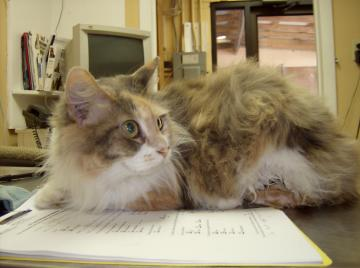

In [ ]:
display(ds["train"][100]['image'])

Testing out best approach

<class 'PIL.JpegImagePlugin.JpegImageFile'>


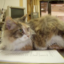

0


In [ ]:
import torchvision.transforms as transforms

print(type(ds["train"][100]['image']))

square_size = 64


transform = transforms.Compose([
    transforms.Resize(size=square_size),
    transforms.CenterCrop(size=square_size)
])

test = transform(ds["train"][100]['image'])
display(test)

print(ds["train"][100]['labels'])

In [ ]:
from huggingface_hub.inference._generated.types import table_question_answering
from torch import square_
import torchvision.transforms as transforms
import torch

square_size = 64

transform = transforms.Compose([
    transforms.Resize(size=square_size),
    transforms.CenterCrop(size=square_size),
    transforms.ToTensor()
])


N = len(ds["train"])

X = torch.Tensor(N, 3, square_size, square_size)
Y = torch.Tensor(N)

with_alpha = 0 #keeping track of images with alpha channel

for i, image in enumerate(ds['train']):

  transformed_image = transform(image['image'])

  X[i] = transformed_image[:3]

  if(transformed_image.shape[0] == 4):
    with_alpha += 1

  Y[i] = image['labels']



In [ ]:
print(with_alpha)

3


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

For my model, I'm going to use a CNN with two convolution layers. I'm going to try 16 output channels for the first layer and 32 for the second. I will also try a fully connected hidden size of 500. Both convolution layers will have a kernel size of 8. I will use  maxpooling layers with 2x2 kernels.

In [ ]:
from torch import nn

class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.sequence = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=8, stride=1, padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout2d(p=0.2),


        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=8, stride=1, padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Flatten(),
        nn.Linear(3200, 500),
        nn.ReLU(),
        nn.Linear(500, 2)
    )
  def forward(self, x):
      logits = self.sequence(x)

      return logits
  def save_first_layer_filters(self, prefix="filter_"):
      first_conv = self.sequence[0]
      weights = first_conv.weight.detach().cpu()

      for i in range(weights.shape[0]):
        filt = weights[i]
        filt_img = filt.permute(1, 2, 0).numpy()*25

        print(filt_img.shape)

        plt.imshow(filt_img)

        plt.show()

        plt.close()

#sanity check
dummy = torch.rand(1, 3, 64, 64)
model = CNN()
print(model(dummy).shape)


torch.Size([1, 2])


In [ ]:
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.data = X.to(torch.float32)
        self.labels = y.to(torch.long)
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

def plot_metric(to_plot, labels, file_name, title="", ylabel="Value"):
  plt.figure()

  for values, label in zip(to_plot, labels):
      plt.plot(values, label=label)

  plt.xlabel("Epoch")
  plt.ylabel(ylabel)
  plt.title(title)
  plt.legend()
  #plt.savefig(file_name)
  plt.show()
  plt.close()


def evaluate(model, dataloader, batch_size=1000, device=torch.device("cuda")):
  model.eval()
  model.to(device)

  criterion = torch.nn.CrossEntropyLoss()

  correct = 0
  total = 0
  total_loss = 0.0

  with torch.no_grad():
    for (X_batch, Y_batch) in dataloader:
      X_batch = X_batch.to(device)
      Y_batch = Y_batch.to(device).long()

      logits = model(X_batch)
      loss = criterion(logits, Y_batch)

      preds = torch.argmax(logits, dim=1)

      correct += (preds == Y_batch).sum().item()
      total += Y_batch.size(0)
      total_loss += loss.item() * Y_batch.size(0)

  avg_loss = total_loss / total
  accuracy = correct / total

  return accuracy, avg_loss

In [ ]:
def train_loop(model: torch.nn.Module, training_set, testing_set, batch_size=32, epochs=10, device=torch.device("cuda")):
  train_dataloader = DataLoader(training_set, batch_size=batch_size, shuffle=True)
  test_dataloader = DataLoader(testing_set, batch_size=batch_size, shuffle=True)

  model.to(device)

  optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.001)
  criterion = torch.nn.CrossEntropyLoss()

  train_losses = []
  test_losses = []

  train_accuracies = []
  test_accuracies = []

  for epoch in range(epochs):
    total_loss = 0.0
    print("Epoch:", epoch)
    for batch_i, (X_batch, Y_batch) in enumerate(train_dataloader):

      model.train()
      X_batch = X_batch.to(device)
      Y_batch = Y_batch.to(device)

      optimizer.zero_grad()

      Y_pred = model(X_batch)
      loss = criterion(Y_pred, Y_batch)
      loss.backward()

      torch.nn.utils.clip_grad_value_(model.parameters(), clip_value=0.1)

      optimizer.step()

      total_loss += loss.item()
      # Removed print of batch accuracy inside the loop for efficiency and clarity
      # print("batch accuracy:", evaluate(model, test_dataloader, device))

    train_acc, train_loss = evaluate(model, train_dataloader, device=device)
    test_acc, test_loss = evaluate(model, test_dataloader, device=device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print("epoch loss:", total_loss)
    print("train acc:", train_acc)
    print("test acc:", test_acc)

  plot_metric([train_losses, test_losses],["train losses", "test losses"], "train_test_losses.png", title="losses vs epoch")
  plot_metric([train_accuracies, test_accuracies],["train accuracy", "test accuracy"], "train_test_accuracy.png", title="accuracy vs epoch")

Epoch: 0
epoch loss: 389.16437473893166
train acc: 0.665420760358821
test acc: 0.6561298590346006
Epoch: 1
epoch loss: 353.14956310391426
train acc: 0.7072832123024348
test acc: 0.6864587782998719
Epoch: 2
epoch loss: 331.49918258190155
train acc: 0.7595044852627082
test acc: 0.7338744126441692
Epoch: 3
epoch loss: 310.42474469542503
train acc: 0.7846005980350278
test acc: 0.7407090986757796
Epoch: 4
epoch loss: 295.5388525426388
train acc: 0.7799551473729176
test acc: 0.7379325074754378
Epoch: 5
epoch loss: 277.37226793169975
train acc: 0.8126868859461769
test acc: 0.7436992738146091
Epoch: 6
epoch loss: 258.8082856684923
train acc: 0.849263135412217
test acc: 0.7565143101238787


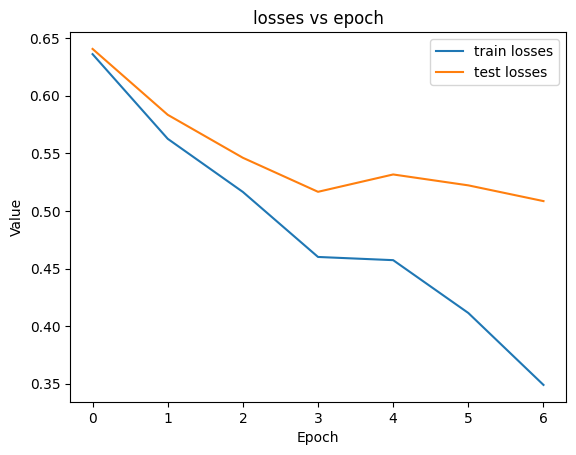

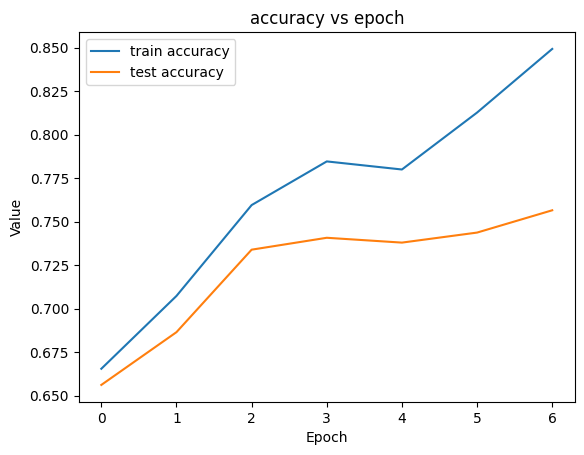

In [ ]:
training_set = CustomDataset(X_train, Y_train)
testing_set = CustomDataset(X_test, Y_test)

device = torch.device("cuda")

model = CNN()
model.to(device)
train_loop(model, training_set, testing_set, batch_size=32, epochs=7, device=device)

(8, 8, 3)


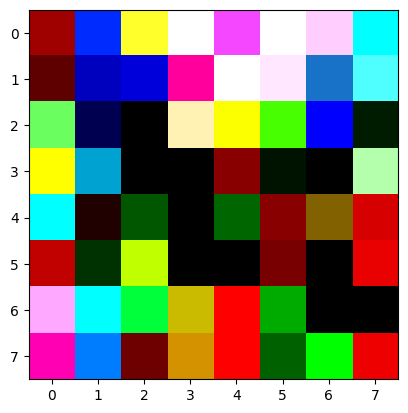

(8, 8, 3)


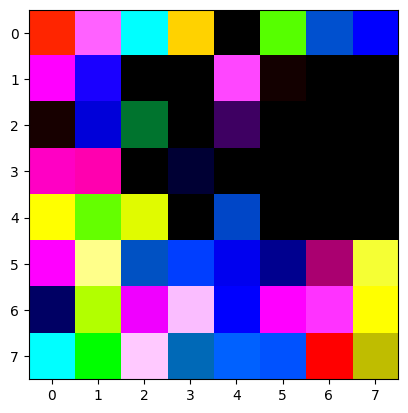

(8, 8, 3)


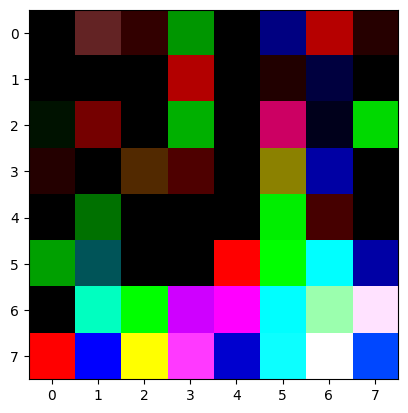

(8, 8, 3)


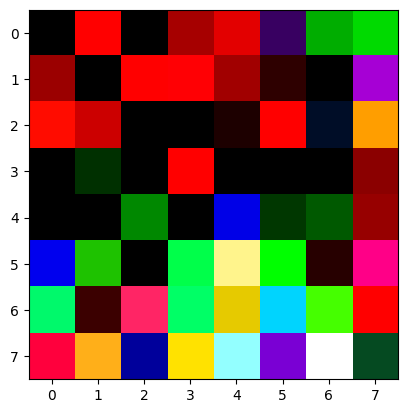

(8, 8, 3)


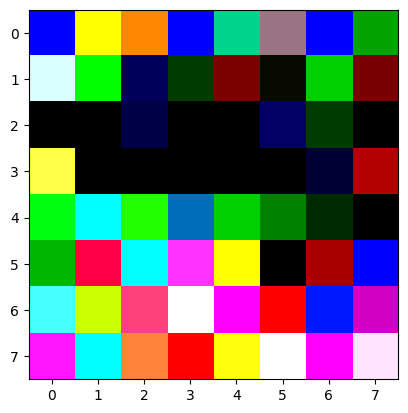

(8, 8, 3)


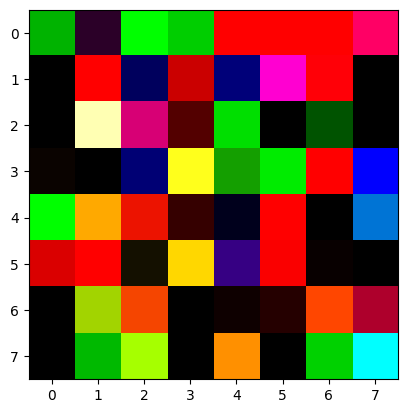

(8, 8, 3)


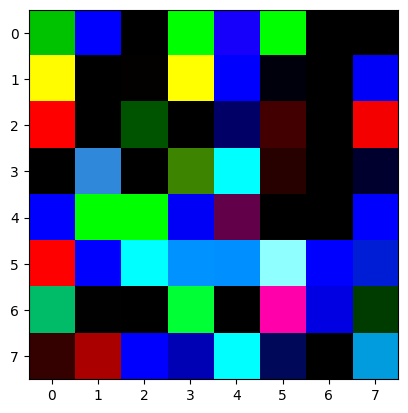

(8, 8, 3)


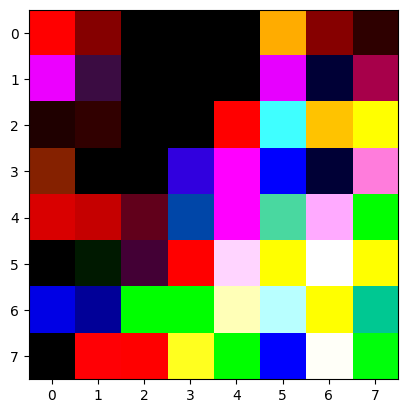

(8, 8, 3)


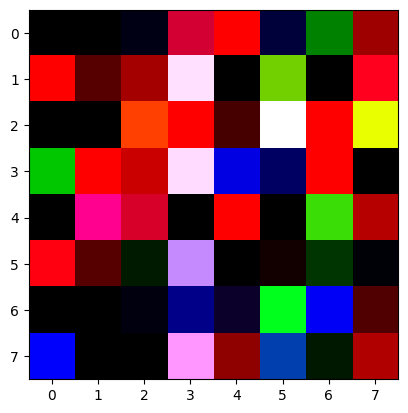

(8, 8, 3)


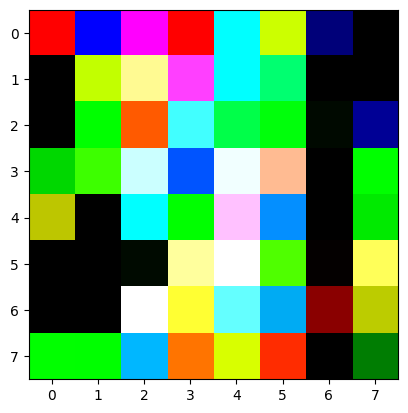

(8, 8, 3)


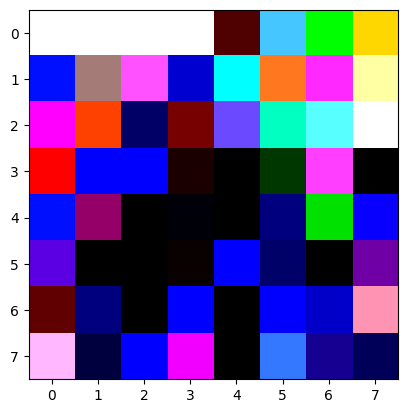

(8, 8, 3)


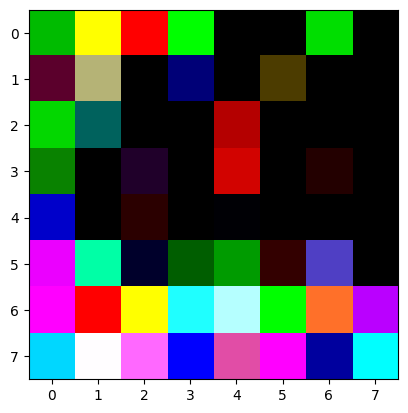

(8, 8, 3)


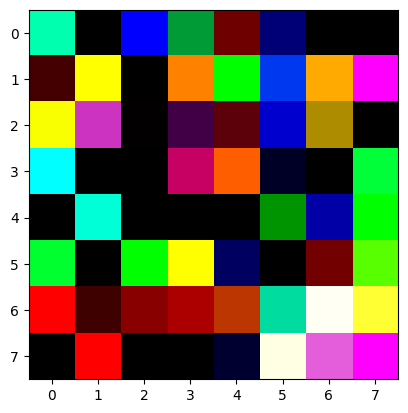

(8, 8, 3)


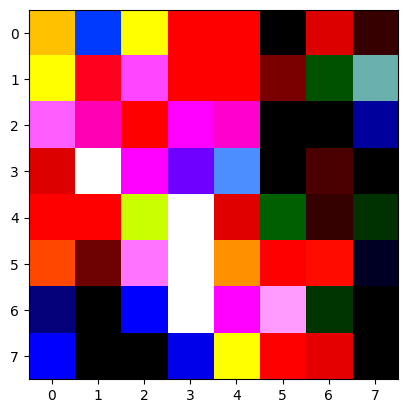

(8, 8, 3)


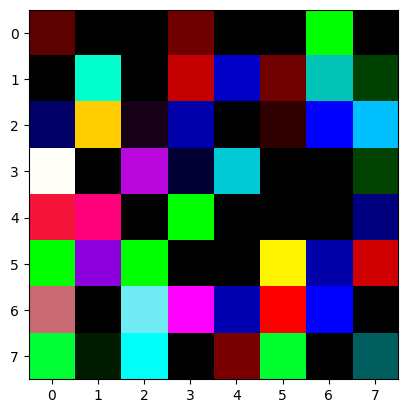

(8, 8, 3)


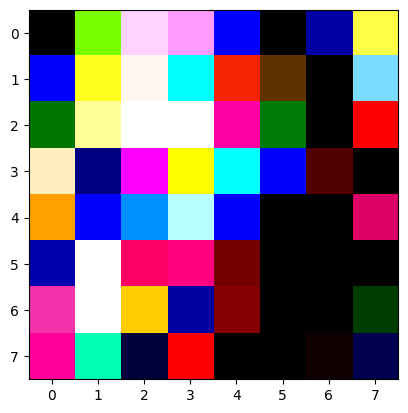

In [ ]:
model.save_first_layer_filters()

Just for fine, I'm displaying the the inital convolution filter weights. They seem not to be just noise, but what exactly they are is kind of abstract. The color is boosted by a flat 25 times.

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.9 MB/s eta 0:00:00


In [ ]:
from torchmetrics import F1Score, Precision, Recall

model.eval()

print(torch.count_nonzero(Y_test))
print(torch.count_nonzero(Y_test == 0))

Y_pred = model(X_test.to(device))

preds = torch.argmax(Y_pred, dim=1)

f1 = F1Score(task="binary",threshold=0.5).to(device)
precision = Precision(task="binary",threshold=0.5).to(device)
recall = Recall(task="binary",threshold=0.5).to(device)

print("f1", f1(preds, Y_test.to(device)))
print("precision", precision(preds, Y_test.to(device)))
print("recall", recall(preds, Y_test.to(device)))

tensor(2338)
tensor(2344)
f1 tensor(0.7549, device='cuda:0')
precision tensor(0.7589, device='cuda:0')
recall tensor(0.7511, device='cuda:0')


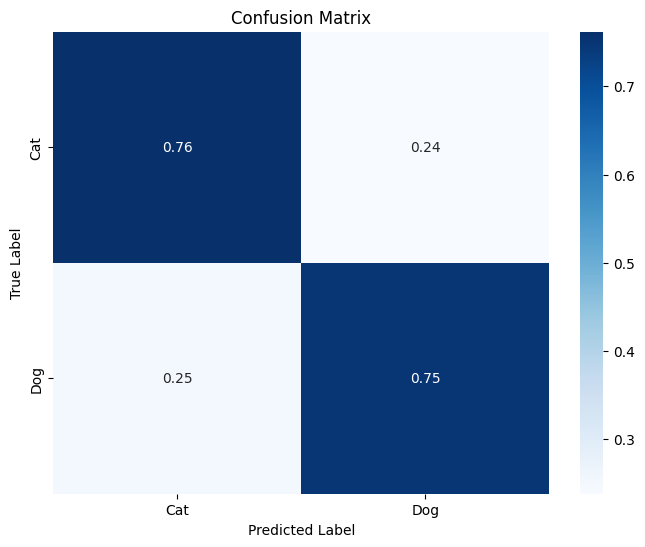

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
model.to(device)

with torch.no_grad():
    Y_pred_logits = model(X_test.to(device))
    preds = torch.argmax(Y_pred_logits, dim=1).cpu().numpy()
    true_labels = Y_test.cpu().numpy()

cm = confusion_matrix(true_labels, preds, normalize="true")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(cm)

[[0.76194539 0.23805461]
 [0.24893071 0.75106929]]


The performance of this model is quite solid! It achieves an F1 score of 0.7549 and an accuracy rate of 0.756.

In the end, in addition to the architecture details, I also used gradient clipping, AdamW optimzer with l2 regularization with weight_dec=0.001, and some light dropout to mitigate overfitting. I used batch gradient descent with a small batch size of 32 and an lr=0.0005.

# transfer learning portion of task

I used this official Pytorch tutorial as reference: [1]


[1] https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

In [ ]:
import torchvision

class resnet_head(torch.nn.Module):

  def __init__(self):
    super().__init__()
    self.model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
    for param in self.model_conv.parameters():
      param.requires_grad = False

    num_ftrs = self.model_conv.fc.in_features
    self.model_conv.fc = torch.nn.Linear(num_ftrs, 2)

  def forward(self, x):
    return self.model_conv(x)



dummy = torch.rand(1, 3, 64, 64)
model = resnet_head()
print(model(dummy).shape)

torch.Size([1, 2])


Epoch: 0
epoch loss: 312.1804702281952
train acc: 0.7730670653566851
test acc: 0.7588637334472448
Epoch: 1
epoch loss: 278.772522225976
train acc: 0.7833724903887228
test acc: 0.7706108500640751
Epoch: 2
epoch loss: 276.9533395320177
train acc: 0.7872703972661256
test acc: 0.7755232806492952
Epoch: 3
epoch loss: 271.0782804340124
train acc: 0.7929837676206749
test acc: 0.7785134557881247
Epoch: 4
epoch loss: 275.7955265045166
train acc: 0.792876975651431
test acc: 0.7785134557881247
Epoch: 5
epoch loss: 275.0204357802868
train acc: 0.7844404100811619
test acc: 0.7682614267407091
Epoch: 6
epoch loss: 273.1469641029835
train acc: 0.7996048697137975
test acc: 0.7836394703118326


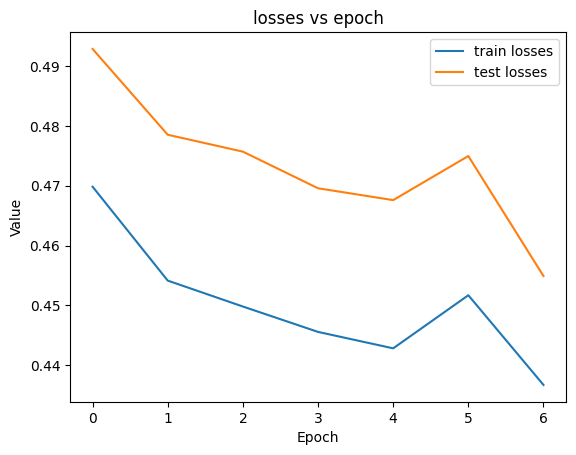

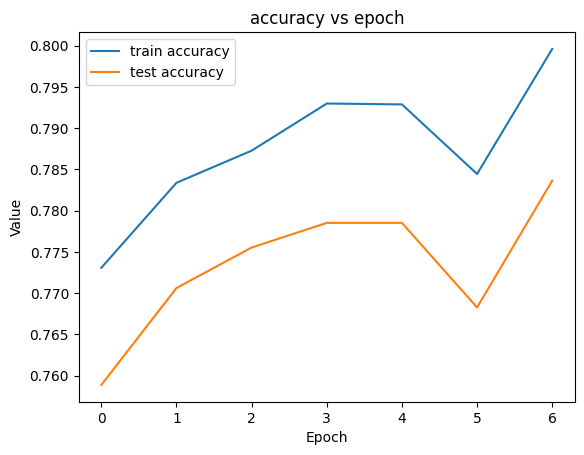

In [ ]:
training_set = CustomDataset(X_train, Y_train)
testing_set = CustomDataset(X_test, Y_test)

device = torch.device("cuda")

model = resnet_head()
model.to(device)
train_loop(model, training_set, testing_set, batch_size=32, epochs=7, device=device)

In [ ]:
from torchmetrics import F1Score, Precision, Recall

model.eval()

print(torch.count_nonzero(Y_test))
print(torch.count_nonzero(Y_test == 0))

Y_pred = model(X_test.to(device))

preds = torch.argmax(Y_pred, dim=1)

f1 = F1Score(task="binary",threshold=0.5).to(device)
precision = Precision(task="binary",threshold=0.5).to(device)
recall = Recall(task="binary",threshold=0.5).to(device)

print("f1", f1(preds, Y_test.to(device)))
print("precision", precision(preds, Y_test.to(device)))
print("recall", recall(preds, Y_test.to(device)))

tensor(2338)
tensor(2344)
f1 tensor(0.7761, device='cuda:0')
precision tensor(0.8048, device='cuda:0')
recall tensor(0.7494, device='cuda:0')


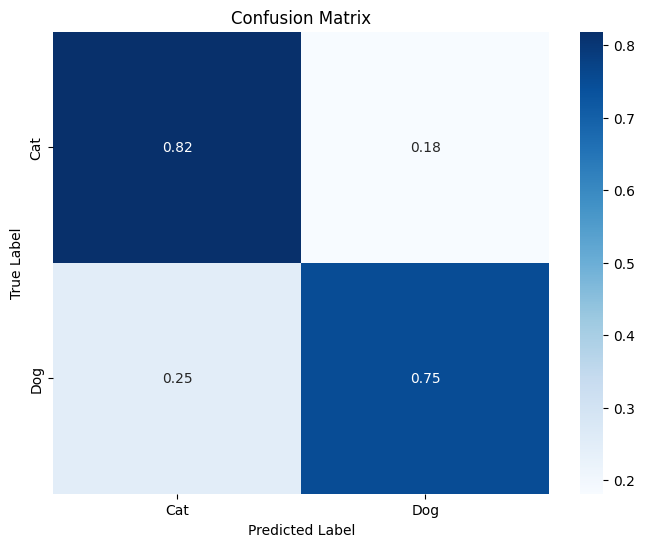

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
model.to(device)

with torch.no_grad():
    Y_pred_logits = model(X_test.to(device))
    preds = torch.argmax(Y_pred_logits, dim=1).cpu().numpy()
    true_labels = Y_test.cpu().numpy()

cm = confusion_matrix(true_labels, preds, normalize="true")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Right out the gate, the pretrained weights outperform the fresh CNN. This makes sense, as ResNet is architecturally more sophisticated than my simple CNN and is probably also pretrained on a vast dataset. It's also actually likely performing a lot worse than it could, as ResNet was trained on images of size 224x224, and I am inputting only 64x64 images.

Now the image augmentation portion of the task.

Epoch: 0
epoch loss: 399.01194924116135
train acc: 0.5509397693293464
test acc: 0.5469884664673217
Epoch: 1
epoch loss: 371.5124317407608
train acc: 0.6607219137120889
test acc: 0.645877829987185
Epoch: 2
epoch loss: 350.38327261805534
train acc: 0.724263135412217
test acc: 0.7054677488252883
Epoch: 3
epoch loss: 332.59509286284447
train acc: 0.7396411789833405
test acc: 0.7195642887654848
Epoch: 4
epoch loss: 316.7863392829895
train acc: 0.7633489961554891
test acc: 0.7360102520290475
Epoch: 5
epoch loss: 300.4838565289974
train acc: 0.7907945322511747
test acc: 0.7411362665527552
Epoch: 6
epoch loss: 280.2767582833767
train acc: 0.803983340452798
test acc: 0.7330200768902179


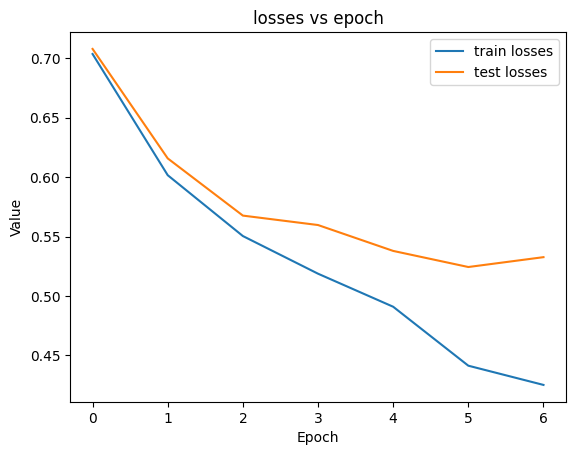

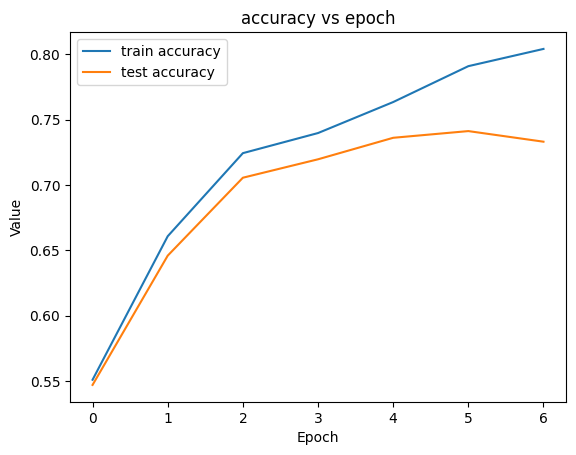

In [ ]:
import random

random.seed(42)

for i in range(len(X_train)):
  if random.randint(1, 20) == 20:
    torch.rot90(X_train[i], k=random.randint(1, 3), dims=[1, 2])

  if random.randint(1, 20) == 20:
    X_train[i] = torch.flip(X_train[i], dims=[1])

  if random.randint(1, 20) == 20:
    X_train[i] = torch.flip(X_train[i], dims=[2])


training_set = CustomDataset(X_train, Y_train)
testing_set = CustomDataset(X_test, Y_test)

device = torch.device("cuda")

model = CNN()
model.to(device)
train_loop(model, training_set, testing_set, batch_size=32, epochs=7, device=device)

Epoch: 0
epoch loss: 317.70717972517014
train acc: 0.770931225971807
test acc: 0.7684750106791969
Epoch: 1
epoch loss: 283.39197343587875
train acc: 0.781877402819308
test acc: 0.7750961127723195
Epoch: 2
epoch loss: 283.97924104332924
train acc: 0.7862024775736864
test acc: 0.7876975651431012
Epoch: 3
epoch loss: 280.7059271335602
train acc: 0.7857219137120889
test acc: 0.7849209739427595
Epoch: 4
epoch loss: 278.25918984413147
train acc: 0.7894062366510038
test acc: 0.790474156343443
Epoch: 5
epoch loss: 278.79934264719486
train acc: 0.770931225971807
test acc: 0.7637761640324647
Epoch: 6
epoch loss: 278.43834388256073
train acc: 0.7835326783425887
test acc: 0.7785134557881247


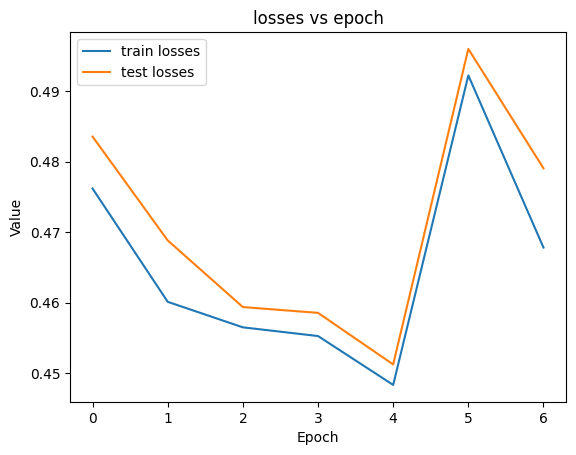

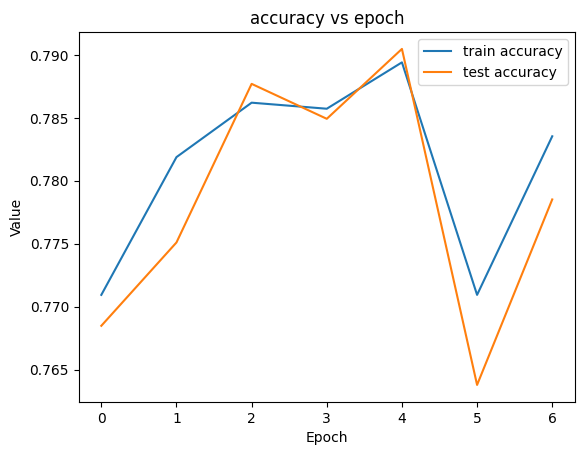

In [ ]:
training_set = CustomDataset(X_train, Y_train)
testing_set = CustomDataset(X_test, Y_test)

device = torch.device("cuda")

model = resnet_head()
model.to(device)
train_loop(model, training_set, testing_set, batch_size=32, epochs=7, device=device)

Since it was ambiguous in the directions, I only transformed training data. I think this tests training robustness better than transforming both does. Between both curves, the training losses and accuracies seemed to worse but the testing accuracies seemed to be about the same. This seems to suggest that transforming the data acts as a kind of regularization technique.

## Task 2

### Part 1

I will be adapting the tutorial from the assignment description for my cats and dogs dataset.

In [ ]:
from IPython import display

import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import tensorflow_probability as tfp
import time


class CVAE(tf.keras.Model):
  """Convolutional variational autoencoder."""

  def __init__(self, latent_dim):
    super(CVAE, self).__init__()
    self.latent_dim = latent_dim
    self.encoder = tf.keras.Sequential(
        [
            tf.keras.layers.InputLayer(input_shape=(64, 64, 3)),
            tf.keras.layers.Conv2D(
                filters=32, kernel_size=3, strides=(2, 2), padding='same', activation='relu'),
            tf.keras.layers.Conv2D(
                filters=64, kernel_size=3, strides=(2, 2), padding='same', activation='relu'),
            tf.keras.layers.Flatten(),
            # No activation
            tf.keras.layers.Dense(latent_dim + latent_dim),
        ]
    )

    self.decoder = tf.keras.Sequential(
        [
            tf.keras.layers.InputLayer(input_shape=(latent_dim,)),
            tf.keras.layers.Dense(units=16*16*32, activation=tf.nn.relu),
            tf.keras.layers.Reshape(target_shape=(16, 16, 32)),
            tf.keras.layers.Conv2DTranspose(
                filters=64, kernel_size=3, strides=2, padding='same',
                activation='relu'),
            tf.keras.layers.Conv2DTranspose(
                filters=32, kernel_size=3, strides=2, padding='same',
                activation='relu'),
            # No activation
            tf.keras.layers.Conv2DTranspose(
                filters=3, kernel_size=3, strides=1, padding='same'),
        ]
    )

  @tf.function
  def sample(self, eps=None):
    if eps is None:
      eps = tf.random.normal(shape=(100, self.latent_dim))
    return self.decode(eps, apply_sigmoid=True)

  def encode(self, x):
    mean, logvar = tf.split(self.encoder(x), num_or_size_splits=2, axis=1)
    return mean, logvar

  def reparameterize(self, mean, logvar):
    eps = tf.random.normal(shape=mean.shape)
    return eps * tf.exp(logvar * .5) + mean

  def decode(self, z, apply_sigmoid=False):
    logits = self.decoder(z)
    if apply_sigmoid:
      probs = tf.sigmoid(logits)
      return probs
    return logits

In [ ]:
optimizer = tf.keras.optimizers.Adam(1e-4)


def log_normal_pdf(sample, mean, logvar, raxis=1):
  log2pi = tf.math.log(2. * np.pi)
  return tf.reduce_sum(
      -.5 * ((sample - mean) ** 2. * tf.exp(-logvar) + logvar + log2pi),
      axis=raxis)


def compute_loss(model, x):
  mean, logvar = model.encode(x)
  z = model.reparameterize(mean, logvar)
  x_logit = model.decode(z)
  cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits=x_logit, labels=x)
  logpx_z = -tf.reduce_sum(cross_ent, axis=[1, 2, 3])
  logpz = log_normal_pdf(z, 0., 0.)
  logqz_x = log_normal_pdf(z, mean, logvar)
  return -tf.reduce_mean(logpx_z + logpz - logqz_x)


@tf.function
def train_step(model, x, optimizer):
  """Executes one training step and returns the loss.

  This function computes the loss and gradients, and uses the latter to
  update the model's parameters.
  """
  with tf.GradientTape() as tape:
    loss = compute_loss(model, x)
  gradients = tape.gradient(loss, model.trainable_variables)
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))

In [ ]:
epochs = 10
# set the dimensionality of the latent space to a plane for visualization later
latent_dim = 2
num_examples_to_generate = 16

# keeping the random vector constant for generation (prediction) so
# it will be easier to see the improvement.
random_vector_for_generation = tf.random.normal(
    shape=[num_examples_to_generate, latent_dim])
model = CVAE(latent_dim)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
def generate_and_save_images(model, epoch, test_sample):
  mean, logvar = model.encode(test_sample)
  z = model.reparameterize(mean, logvar)
  predictions = model.sample(z)
  fig = plt.figure(figsize=(4, 4))

  for i in range(predictions.shape[0]):
    plt.subplot(4, 4, i + 1)
    plt.imshow(predictions[i, :, :, 0], cmap='gray')
    plt.axis('off')

  # tight_layout minimizes the overlap between 2 sub-plots
  plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show()

In [ ]:
test_sample_torch = X_train[0:num_examples_to_generate]

test_sample = test_sample_torch.permute(0, 2, 3, 1)

test_sample = tf.convert_to_tensor(test_sample.numpy(), dtype=tf.float32)

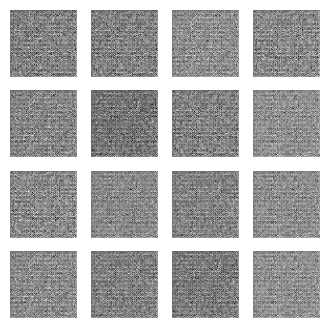

In [ ]:
generate_and_save_images(model, 0, test_sample)

In [ ]:
X_train_keras = X_train.permute(0, 2, 3, 1)
X_test_keras = X_test.permute(0, 2, 3, 1)

X_train_keras = tf.convert_to_tensor(X_train_keras.numpy(), dtype=tf.float32)
X_test_keras = tf.convert_to_tensor(X_test_keras.numpy(), dtype=tf.float32)

Epoch: 10, Test set ELBO: -7954.103515625, time elapse for current epoch: 81.35971903800964


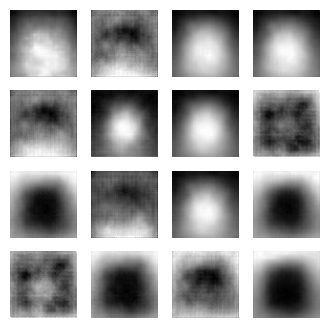

In [ ]:
generate_and_save_images(model, 0, test_sample)

for epoch in range(1, epochs + 1):
  start_time = time.time()
  for train_x in X_train_keras:
    train_step(model, tf.expand_dims(train_x, axis=0), optimizer)
  end_time = time.time()

  loss = tf.keras.metrics.Mean()
  for test_x in X_test_keras:
    loss(compute_loss(model, tf.expand_dims(test_x, axis=0)))
  elbo = -loss.result()
  display.clear_output(wait=False)
  print('Epoch: {}, Test set ELBO: {}, time elapse for current epoch: {}'
        .format(epoch, elbo, end_time - start_time))
  generate_and_save_images(model, epoch, test_sample)

Here is the VAE performance after 10 epochs. Clearly, it's learned something if you compare it to the samples from earlier. You can make out the figure of the animals and certain features like ears and feint eyes, but overall the image is not very clear. The model is adapted from the tutorial model which is designed for MNIST, so I probably need a larger and more complex model to generate quality images of the animals.

For reasons of time, I did not do the GAN implementation.